In [3]:
import pandas as pd
import os,torch,collections
import numpy as np
#go through formual mask ious in overlap/ and record how ovvverlap changes across iters for each pruning
root="/workspace/CCE_NLI/BERT/overlap/lottery_ticket/Run2Full/"


def convert(x):
    if isinstance(x, str) and x.startswith('tensor'):
        # Remove 'torch.tensor(' and ')' to get the list
        tensor_str = x[7:-1]
        return torch.tensor(eval(tensor_str)).item()
    elif isinstance(x, str):
        # If the entry is a number (int or float), convert it to a tensor
        return float(x)
    else:
        # If the entry is already a tensor, return it as is
        return x
from sortedcontainers import SortedDict
pruned_percents=[0.0, 0.2, 0.36, 0.48799967447916665, 0.590400390625, 0.6723209635416667, 0.7378564453125, 0.7902848307291667, 0.8322281901041667, 0.8657828776041666, 0.892626953125, 0.9141015625, 0.9312809244791667, 0.9450244140625, 0.9560188802083334]
def get_aligments(root, active_neuron_per_cluster):
    stored_alignments=collections.defaultdict(lambda : collections.defaultdict())
    for cluster in os.listdir(os.path.join(root)):
        if '.ipynb_checkpoints' in cluster: continue
        for alignment in os.listdir(os.path.join(root, cluster)):
            if alignment == '.ipynb_checkpoints': continue
            file = os.path.join(root, cluster, alignment)
            overlap_file = pd.read_csv(file)
            overlap_file['iou'] = overlap_file['iou'].apply(lambda x: convert(x))
            overlap_file['neuron']= overlap_file['neuron'].apply(lambda x: int(x))
            active_neurons = {}
            for neuron, iou in zip(overlap_file['neuron'], overlap_file['iou']):
                active_neurons[neuron] = np.round(iou,3)
            for neuron in active_neuron_per_cluster[int(cluster[7:])-1]:
                if neuron not in active_neurons:
                    active_neurons[neuron] = 0
               
            pruning_iter = int(alignment[:alignment.index('I')]) 
            stored_alignments[pruned_percents[pruning_iter]*100][cluster] = SortedDict(active_neurons)
    return stored_alignments
    

        
    

#get all neurons in 0% pruning
#go to all other files:
stored_alignments=get_aligments(root, active_neuron_per_cluster)

NameError: name 'active_neuron_per_cluster' is not defined

In [4]:
def get_avg_alignment(stored_alignments):
    alignment_change_c1={}
    min_change_c1={}
    max_change_c1 ={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster1' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster1'].values())
            avg = sum(ious)/len(ious)
            min_ = min([x for x in ious if x != 0])
            max_ = max(ious)
        else:
            avg=0
        alignment_change_c1[per] = avg
        min_change_c1[per] = min_
        max_change_c1[per] = max_

    alignment_change_c2={}
    min_change_c2={}
    max_change_c2 ={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster2' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster2'].values())
            avg = sum(ious)/len(ious)
            min_ = min([x for x in ious if x != 0])
            max_ = max(ious)
        else:
            avg=0
        alignment_change_c2[per] = avg
        min_change_c2[per] = min_
        max_change_c2[per] = max_

    alignment_change_c3={}
    min_change_c3={}
    max_change_c3={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster3' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster3'].values())
            avg = sum(ious)/len(ious)
            min_ = min(ious)
            max_ = max(ious)
            alignment_change_c3[per] = avg
            min_change_c3[per] = min_
            max_change_c3[per] = max_
    align_changes = [alignment_change_c1, alignment_change_c2, alignment_change_c3]
    min_changes = [min_change_c1, min_change_c2, min_change_c3]
    max_changes = [max_change_c1, max_change_c2, max_change_c3]
    return align_changes, min_changes, max_changes

In [5]:
stored_alignments

NameError: name 'stored_alignments' is not defined

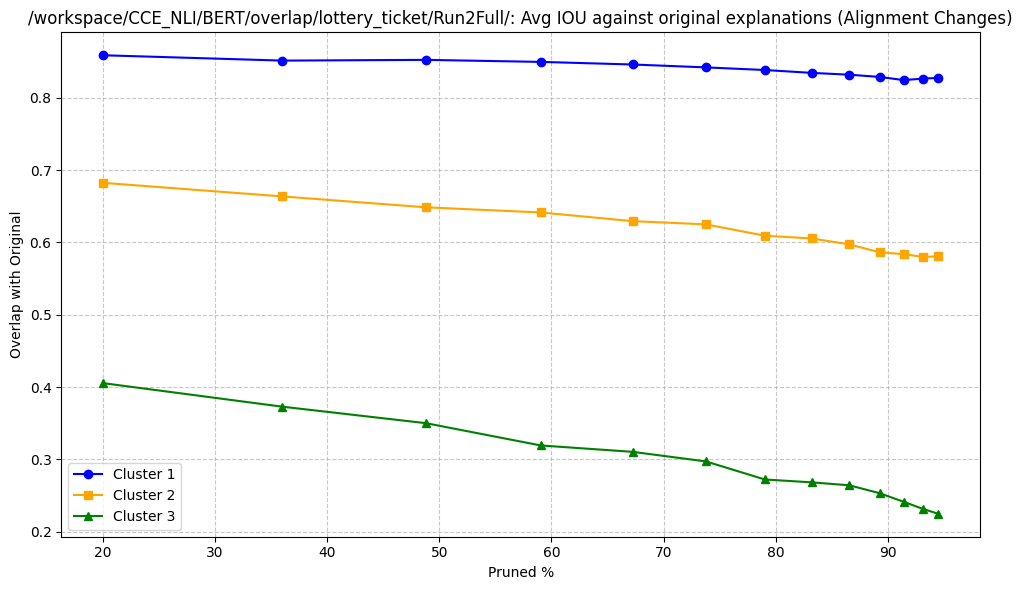

In [10]:
root ="/workspace/CCE_NLI/BERT/overlap/lottery_ticket/Run2Full/"
bowman_lth_c1 = pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
bowman_lth_c2 = pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
bowman_lth_c3 = pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']
c1=bowman_lth_c1
c2=bowman_lth_c2
c3=bowman_lth_c3
active_neuron_per_cluster=[c1,c2,c3]
stored_alignments=get_aligments(root, active_neuron_per_cluster)
alignment_changes, min_changes, max_changes = get_avg_alignment(stored_alignments)
plot(root,alignment_changes, min_changes, max_changes)

In [7]:
import matplotlib.pyplot as plt
def plot(root, alignment_changes, mins, maxs):
    """
    Create three plots, each highlighting a different cluster's min/max range
    
    Parameters:
    - method: str, title prefix for the plots
    - alignment_changes: tuple of (c1, c2, c3) dictionaries with alignment values
    - mins: tuple of (min1, min2, min3) dictionaries with minimum values
    - maxs: tuple of (max1, max2, max3) dictionaries with maximum values
    """
    alignment_change_c1, alignment_change_c2, alignment_change_c3 = alignment_changes
    min1, min2, min3 = mins
    max1, max2, max3 = maxs
    
    # Define cluster colors for consistency
    colors = {'c1': 'blue', 'c2': 'orange', 'c3': 'green'}
    markers = {'c1': 'o', 'c2': 's', 'c3': '^'}
    
    def create_single_plot():
        plt.figure(figsize=(10, 6))
        
        # Plot all three lines
        plt.plot(list(alignment_change_c1.keys()), list(alignment_change_c1.values()), 
                label='Cluster 1', marker=markers['c1'], color=colors['c1'])
        plt.plot(list(alignment_change_c2.keys()), list(alignment_change_c2.values()), 
                label='Cluster 2', marker=markers['c2'], color=colors['c2'])
        plt.plot(list(alignment_change_c3.keys()), list(alignment_change_c3.values()), 
                label='Cluster 3', marker=markers['c3'], color=colors['c3'])
        
       
        
        # Customize the plot
        plt.xlabel('Pruned %')
        plt.ylabel('Overlap with Original')
        plt.title(f'{root}: Avg IOU against original explanations (Alignment Changes)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.margins(x=0.05)
        plt.tight_layout()
        plt.show()
    create_single_plot()
    # Create three plots, each highlighting a different cluster
    

In [8]:
root = root="/workspace/CCE_NLI/BOWMAN/overlap/wanda/Run1/"
bowman_wanda_c1 = pd.read_csv("/workspace/CCE_NLI/BOWMAN/exp/wanda/Run1/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
bowman_wanda_c2 = pd.read_csv("/workspace/CCE_NLI/BOWMAN/exp/wanda/Run1/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
bowman_wanda_c3 = pd.read_csv("/workspace/CCE_NLI/BOWMAN/exp/wanda/Run1/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']
c1=bowman_wanda_c1
c2=bowman_wanda_c2
c3=bowman_wanda_c3
active_neuron_per_cluster=[c1,c2,c3]
stored_alignments=get_aligments(root, active_neuron_per_cluster)
alignment_changes, min_changes, max_changes = get_avg_alignment(stored_alignments)
plot(root,alignment_changes, min_changes, max_changes)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/wanda/Run1/Expls/0.0%Pruned/Cluster1IOUS1024N.csv'